# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

this dataset represents 17 campaigns.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [137]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [138]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [139]:
# Let's check for missing values in the dataset
df.isnull().sum().to_frame(name='Missing Values').sort_values(by='Missing Values', ascending=False)

,Missing Values
age,0
campaign,0
nr.employed,0
euribor3m,0
cons.conf.idx,0
cons.price.idx,0
emp.var.rate,0
poutcome,0
previous,0
pdays,0


In [140]:
# Convert day_of_week to datetime
df['day_of_week'] = df['day_of_week'].str.capitalize().replace(' ','')
df['day_of_week'].head()

0    Mon
1    Mon
2    Mon
3    Mon
4    Mon
Name: day_of_week, dtype: object

In [141]:
# Convert month to datetime
df['month'] = pd.to_datetime(df['month'], format='%b').dt.month_name()
df['month'].head()

0    May
1    May
2    May
3    May
4    May
Name: month, dtype: object

In [142]:
# Check what % of entry for duration is zero
zero_duration_percentage = (df['duration'] == 0).mean() * 100
print(f"Percentage of entries with zero duration: {zero_duration_percentage:.2f}%")
# Check what % of entry for pdays is 999
zero_pdays_percentage = (df['pdays'] == 999).mean() * 100
print(f"Percentage of entries with pdays as 999: {zero_pdays_percentage:.2f}%")
# Check what % of entry for previous is zero
zero_previous_percentage = (df['previous'] == 0).mean() * 100
print(f"Percentage of entries with previous as 0: {zero_previous_percentage:.2f}%")

Percentage of entries with zero duration: 0.01%
Percentage of entries with pdays as 999: 96.32%
Percentage of entries with previous as 0: 86.34%


In [143]:
# Since duration is crucial for predicting the target variable, we will remove entries with zero duration
df = df[df['duration'] != 0]
# Since large portion of pdays is 999, we will drop this column
df = df.drop(columns=['pdays'])
# Since large portion of previous is 0, we will drop this column
df = df.drop(columns=['previous'])

In [144]:
# Convert categorical variables to category dtype
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df[col] = df[col].astype('category')
# Convert target variable to binary
df['y'] = df['y'].map({'yes': 1, 'no': 0}).astype('boolean')

Target variable distribution (%):
y
False    88.733489
True     11.266511
Name: proportion, dtype: Float64


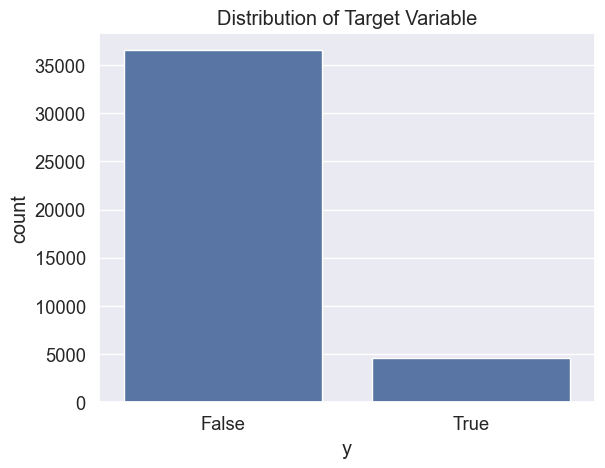

In [145]:
# Check the distribution of the target variable
target_distribution = df['y'].value_counts(normalize=True) * 100
print("Target variable distribution (%):")
print(target_distribution)
# Visualize the target variable distribution
sns.countplot(x='y', data=df)
plt.title('Distribution of Target Variable')
# Save image to file
plt.savefig('images/target_distribution.png')
plt.show()

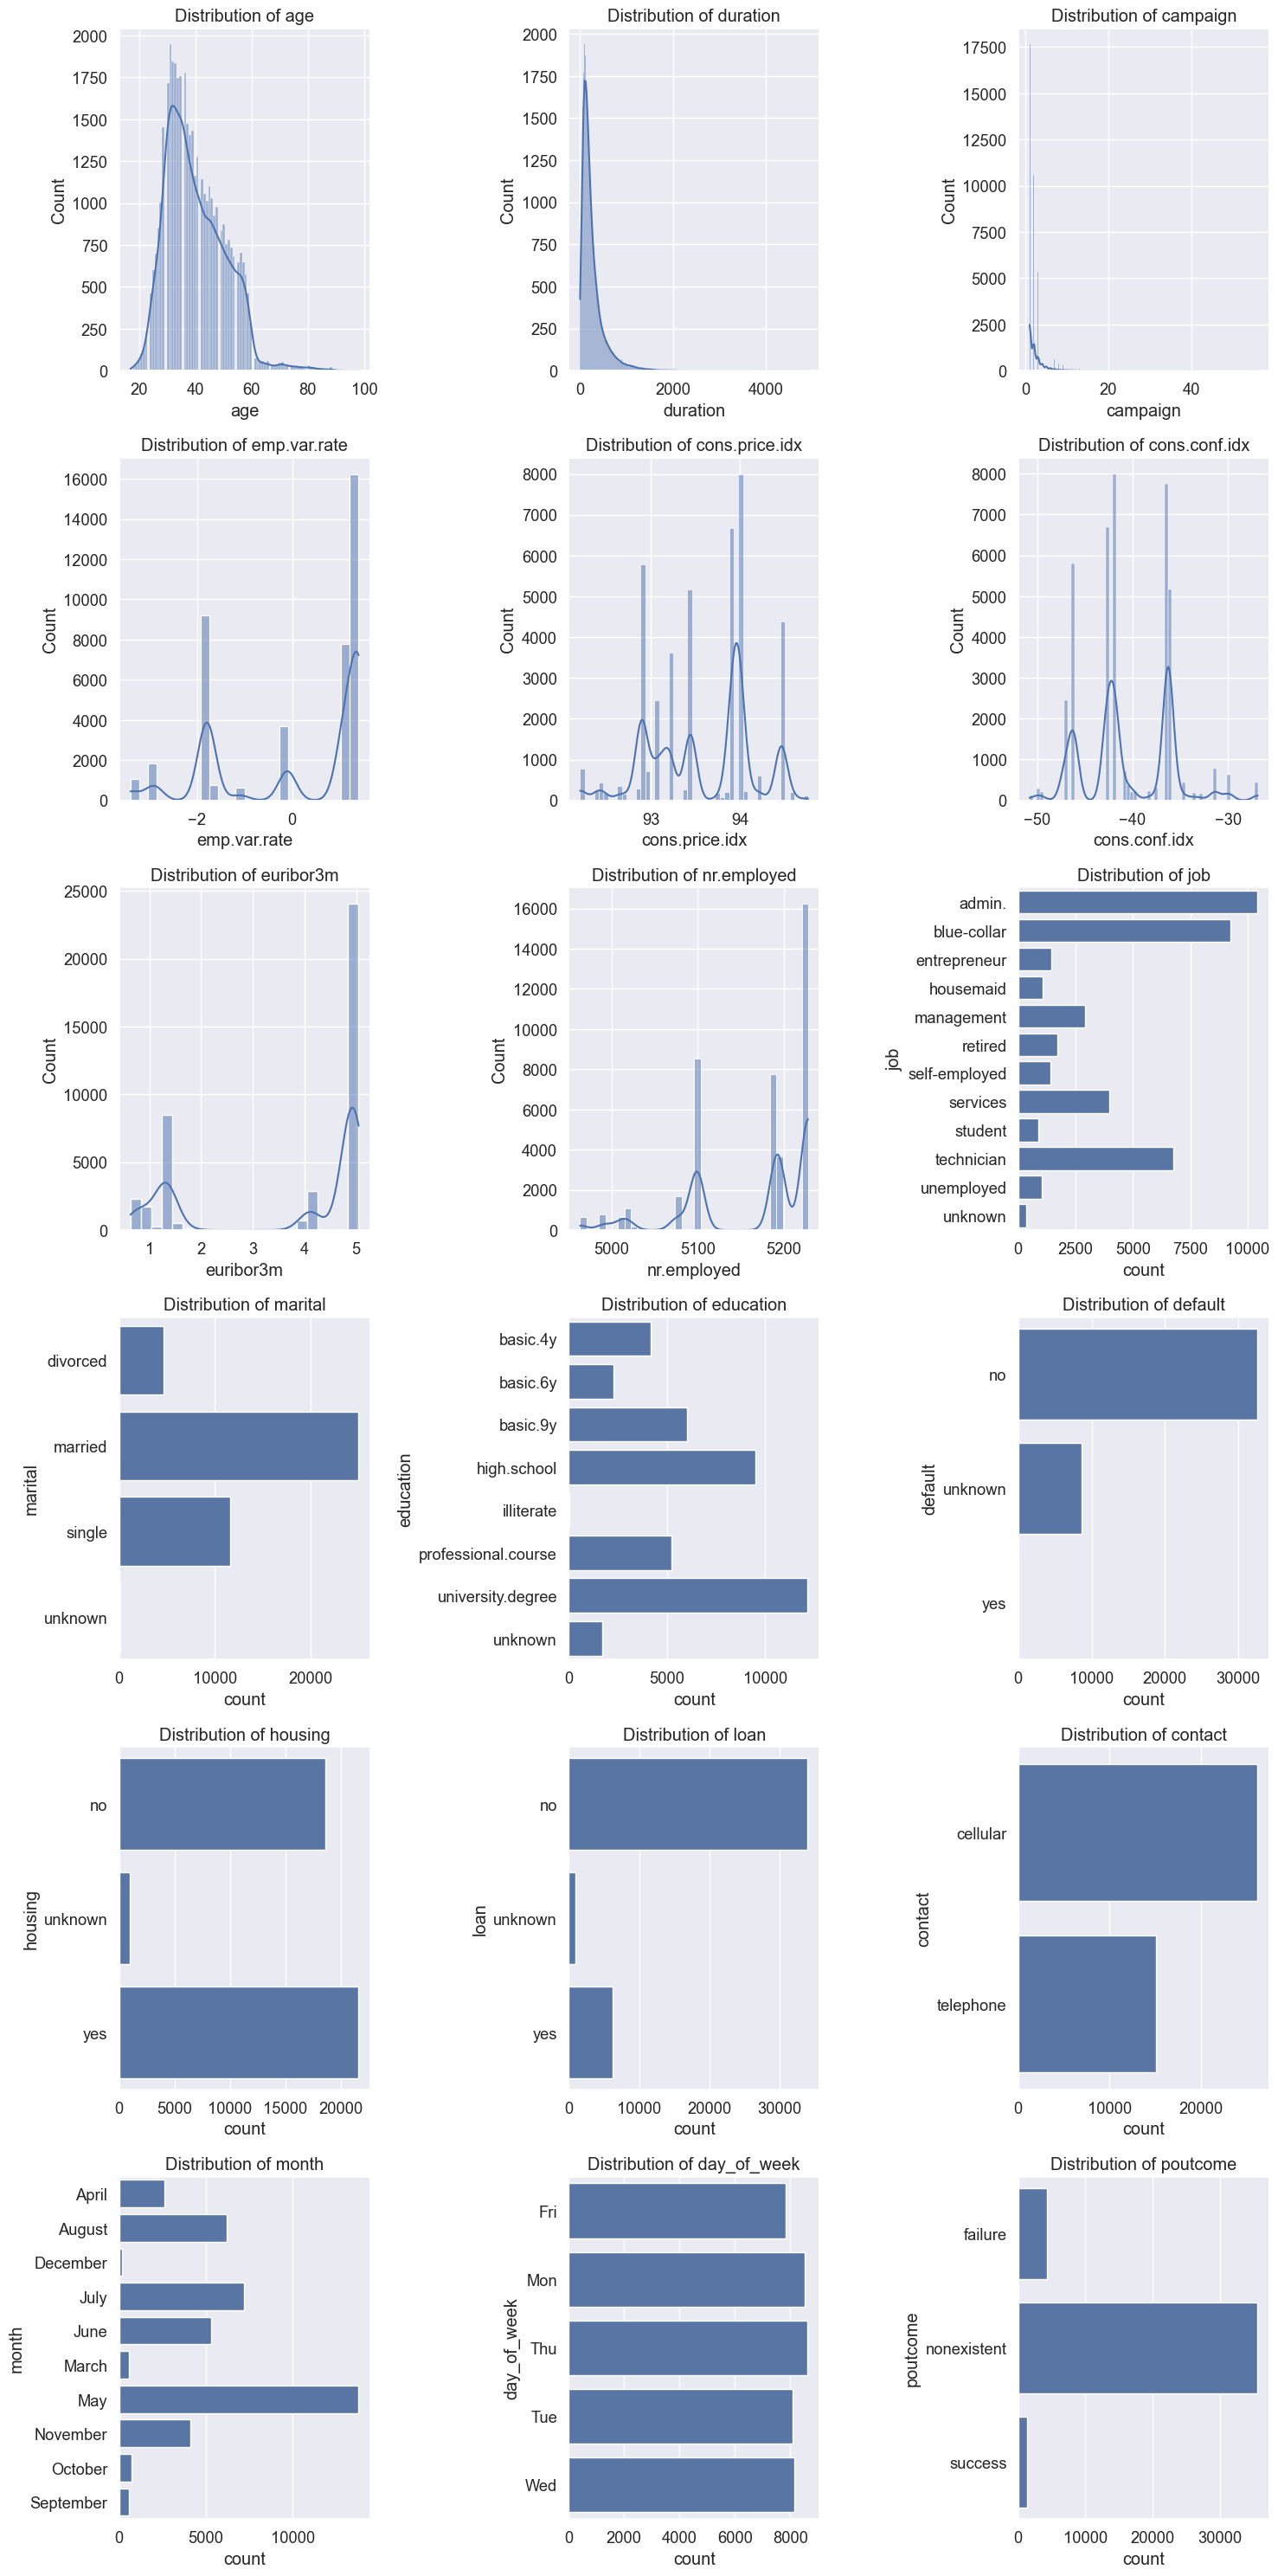

In [146]:
# Create univariate plots for all features in a grid layout
def plot_univariate(df):
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    cat_cols = df.select_dtypes(include='category').columns.tolist()
    date_cols = df.select_dtypes(include='datetime').columns.tolist()

    total_plots = len(num_cols) + len(cat_cols) + len(date_cols)
    cols = 3
    rows = (total_plots // cols) + (total_plots % cols > 0)
    
    plt.figure(figsize=(15, rows * 5))
    
    for i, col in enumerate(num_cols + cat_cols + date_cols):
        plt.subplot(rows, cols, i + 1)
        if col in num_cols:
            sns.histplot(df[col], kde=True)
        else:
            sns.countplot(y=col, data=df)
        plt.title(f'Distribution of {col}')
    
    plt.tight_layout()
    plt.savefig('images/univariate_plots.png')
    plt.show()
plot_univariate(df)

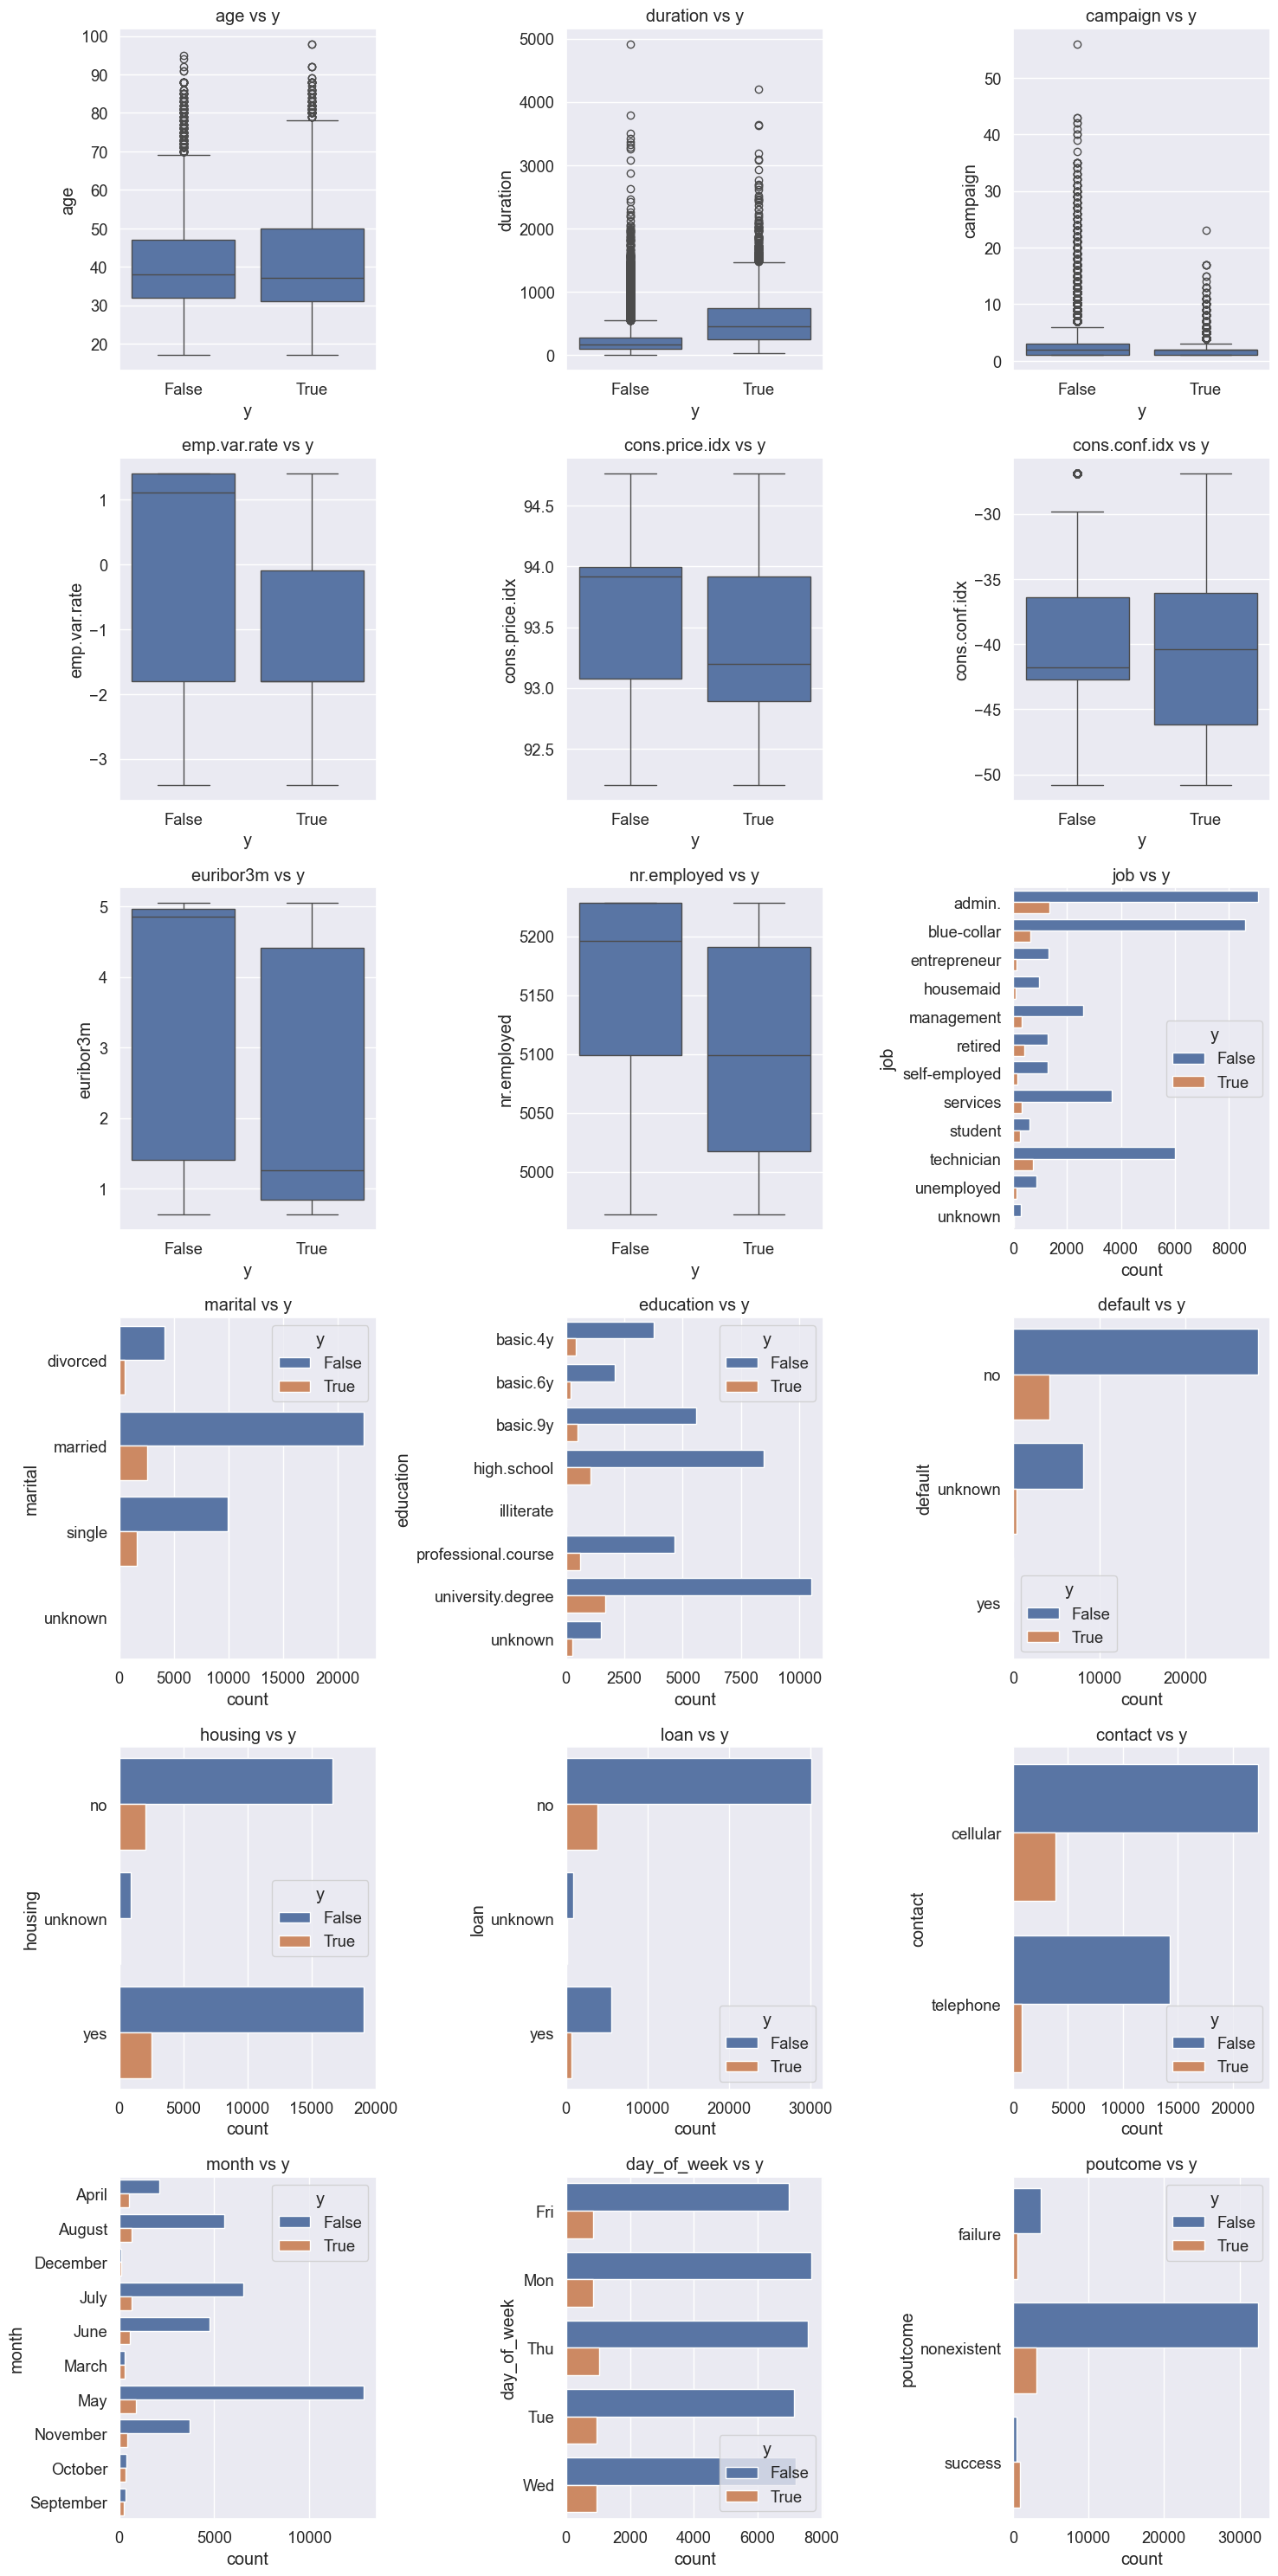

In [147]:
# Create bivariate plots for all features against the target variable in a grid layout
def plot_bivariate(df, target):
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    cat_cols = df.select_dtypes(include='category').columns.tolist()
    
    total_plots = len(num_cols) + len(cat_cols)
    cols = 3
    rows = (total_plots // cols) + (total_plots % cols > 0)
    
    plt.figure(figsize=(15, rows * 5))
    
    for i, col in enumerate(num_cols + cat_cols):
        plt.subplot(rows, cols, i + 1)
        if col in num_cols:
            sns.boxplot(x=target, y=col, data=df)
        else:
            sns.countplot(y=col, hue=target, data=df)
        plt.title(f'{col} vs {target}')
    
    plt.tight_layout()
    plt.savefig('images/bivariate_plots.png')
    plt.show()
plot_bivariate(df, 'y')

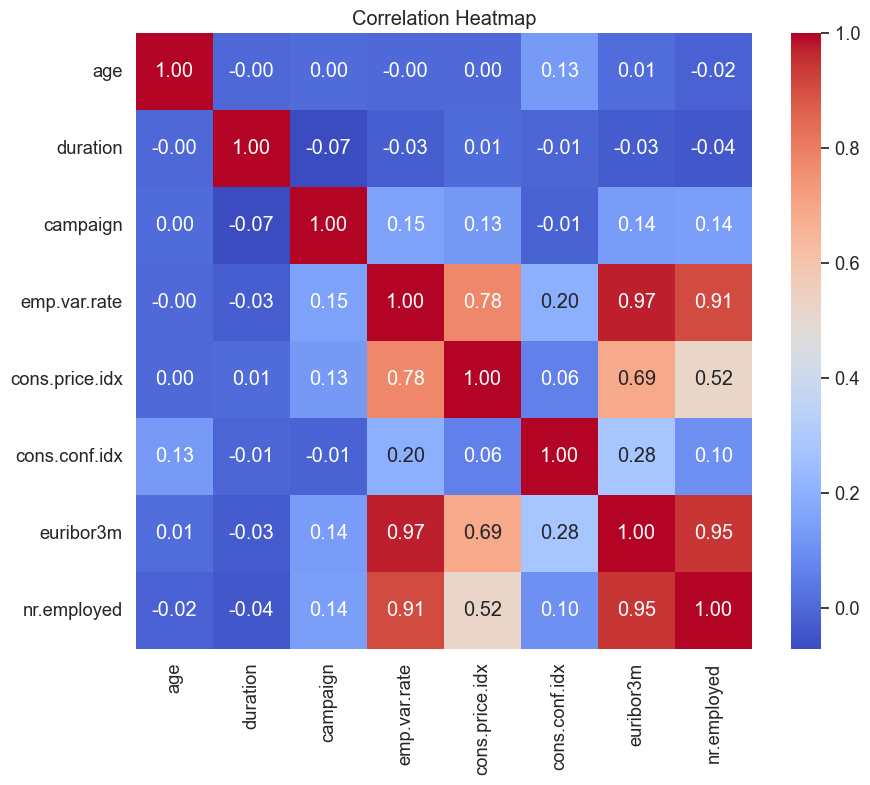

In [148]:
# Create correlation heatmap for numerical features
def plot_correlation_heatmap(df):
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    corr = df[num_cols].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
    plt.title('Correlation Heatmap')
    plt.savefig('images/correlation_heatmap.png')
    plt.show()
plot_correlation_heatmap(df)


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41184 entries, 0 to 41187
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             41184 non-null  int64   
 1   job             41184 non-null  category
 2   marital         41184 non-null  category
 3   education       41184 non-null  category
 4   default         41184 non-null  category
 5   housing         41184 non-null  category
 6   loan            41184 non-null  category
 7   contact         41184 non-null  category
 8   month           41184 non-null  category
 9   day_of_week     41184 non-null  category
 10  duration        41184 non-null  int64   
 11  campaign        41184 non-null  int64   
 12  poutcome        41184 non-null  category
 13  emp.var.rate    41184 non-null  float64 
 14  cons.price.idx  41184 non-null  float64 
 15  cons.conf.idx   41184 non-null  float64 
 16  euribor3m       41184 non-null  float64 
 17  nr.employed     4

In [150]:
# Save the cleaned data to a new CSV file
df.to_csv('data/bank_additional_cleaned.csv', index=False)

## Objective
Using banking campaign information provided, create model to predict the outcome of a client subscribing to the term deposit.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [157]:
# Load the cleaned data
df = pd.read_csv('data/bank_additional_cleaned.csv')

In [158]:
# Separate X and y for modeling
X = df.drop('y', axis=1)
y = df['y']

In [159]:
# Converting categorical variables to dummy variables
X = pd.get_dummies(X)
X.shape

(41184, 61)

In [160]:
X.columns

Index(['age', 'duration', 'campaign', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'marital_unknown', 'education_basic.4y', 'education_basic.6y',
       'education_basic.9y', 'education_high.school', 'education_illiterate',
       'education_professional.course', 'education_university.degree',
       'education_unknown', 'default_no', 'default_unknown', 'default_yes',
       'housing_no', 'housing_unknown', 'housing_yes', 'loan_no',
       'loan_unknown', 'loan_yes', 'contact_cellular', 'contact_telephone',
       'month_April', 'month_August', 'month_December', 'month_July',
       'month_June', 'month_March', 'month_May', 'month_November',
       'mon

In [161]:
X.head()

,age,duration,campaign,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_admin.,job_blue-collar,...,month_October,month_September,day_of_week_Fri,day_of_week_Mon,day_of_week_Thu,day_of_week_Tue,day_of_week_Wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,56,261,1,1.1,93.994,-36.4,4.857,5191.0,False,False,...,False,False,False,True,False,False,False,False,True,False
1,57,149,1,1.1,93.994,-36.4,4.857,5191.0,False,False,...,False,False,False,True,False,False,False,False,True,False
2,37,226,1,1.1,93.994,-36.4,4.857,5191.0,False,False,...,False,False,False,True,False,False,False,False,True,False
3,40,151,1,1.1,93.994,-36.4,4.857,5191.0,True,False,...,False,False,False,True,False,False,False,False,True,False
4,56,307,1,1.1,93.994,-36.4,4.857,5191.0,False,False,...,False,False,False,True,False,False,False,False,True,False


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [162]:
# Splitting the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set shape: {X_train.shape}, Testing set shape: {X_test.shape}")


Training set shape: (32947, 61), Testing set shape: (8237, 61)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [163]:
# Let's find out baseline accuracy by predicting the majority class
baseline_accuracy = y_train.value_counts(normalize=True).max()
print(f"Baseline accuracy (majority class): {baseline_accuracy:.2f}")

Baseline accuracy (majority class): 0.89


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [174]:
# Build a basic logistic regression model
from sklearn.linear_model import LogisticRegression
import time
# Initialize the model
basic_lgr_model = LogisticRegression(max_iter=1000)

# Train the model and record the time taken
start_basic_lgr_time = time.time()
basic_lgr_model.fit(X_train, y_train)
basic_lgr_train_time = time.time() - start_basic_lgr_time

# Evaluate the basic model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred_basic_lgr = basic_lgr_model.predict(X_test)

/opt/anaconda3/envs/ucb_py312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Problem 9: Score the Model

What is the accuracy of your model?

In [176]:
# Print the time taken to train the model
print(f"Time taken to train Basic Logistic Regression Model: {basic_lgr_train_time:.2f} seconds")
# train accuracy
basic_lgr_train_accuracy = accuracy_score(y_train, basic_lgr_model.predict(X_train))
print(f"Basic Logistic Regression Model Train Accuracy: {basic_lgr_train_accuracy:.2f}")
# test accuracy
basic_lgr_test_accuracy = accuracy_score(y_test, y_pred_basic_lgr)
print(f"Basic Logistic Regression Model Test Accuracy: {basic_lgr_test_accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_basic_lgr))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_basic_lgr))

Time taken to train Basic Logistic Regression Model: 4.36 seconds
Basic Logistic Regression Model Train Accuracy: 0.91
Basic Logistic Regression Model Test Accuracy: 0.91
Classification Report:
              precision    recall  f1-score   support

       False       0.93      0.98      0.95      7309
        True       0.68      0.42      0.52       928

    accuracy                           0.91      8237
   macro avg       0.81      0.70      0.74      8237
weighted avg       0.90      0.91      0.90      8237

Confusion Matrix:
[[7129  180]
 [ 538  390]]


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [177]:
# Build basic KNN model
from sklearn.neighbors import KNeighborsClassifier

# Initialize the model
basic_knn_model = KNeighborsClassifier()

# Train the model and capture the time taken
start_basic_knn_time = time.time()
basic_knn_model.fit(X_train, y_train)
basic_knn_train_time = time.time() - start_basic_knn_time

# Evaluate the basic KNN model
y_pred_basic_knn = basic_knn_model.predict(X_test)

# Print the time taken to train the model
print(f"Time taken to train Basic KNN Model: {basic_knn_train_time:.2f} seconds")
# Calculate train accuracy
basic_knn_train_accuracy = accuracy_score(y_train, basic_knn_model.predict(X_train))
print(f"Basic KNN Model Train Accuracy: {basic_knn_train_accuracy:.2f}")
# Calculate test accuracy
basic_knn_test_accuracy = accuracy_score(y_test, y_pred_basic_knn)
print(f"Basic KNN Model Accuracy: {basic_knn_test_accuracy:.2f}")

# Print the classification report and confusion matrix
print("Classification Report:")
print(classification_report(y_test, y_pred_basic_knn))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_basic_knn))

Time taken to train Basic KNN Model: 0.01 seconds
Basic KNN Model Train Accuracy: 0.93
Basic KNN Model Accuracy: 0.90
Classification Report:
              precision    recall  f1-score   support

       False       0.94      0.96      0.95      7309
        True       0.58      0.48      0.53       928

    accuracy                           0.90      8237
   macro avg       0.76      0.72      0.74      8237
weighted avg       0.90      0.90      0.90      8237

Confusion Matrix:
[[6986  323]
 [ 482  446]]


In [178]:
# Build basic Decision Tree model
from sklearn.tree import DecisionTreeClassifier

# Initialize the model
basic_dt_model = DecisionTreeClassifier(random_state=42)

# Train the model and capture the time taken
start_basic_dt_time = time.time()
basic_dt_model.fit(X_train, y_train)
basic_dt_train_time = time.time() - start_basic_dt_time

# Print the time taken to train the model
print(f"Time taken to train Basic Decision Tree Model: {basic_dt_train_time:.2f} seconds")

# Calculate train accuracy
basic_dt_train_accuracy = accuracy_score(y_train, basic_dt_model.predict(X_train))
print(f"Basic Decision Tree Model Train Accuracy: {basic_dt_train_accuracy:.2f}")

# Calculate test accuracy
y_pred_basic_dt = basic_dt_model.predict(X_test)
basic_dt_test_accuracy = accuracy_score(y_test, y_pred_basic_dt)
print(f"Basic Decision Tree Model Accuracy: {basic_dt_test_accuracy:.2f}")

# Evaluate the basic Decision Tree model
# Print the classification report and confusion matrix
print("Classification Report:")
print(classification_report(y_test, y_pred_basic_dt))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_basic_dt))

Time taken to train Basic Decision Tree Model: 0.17 seconds
Basic Decision Tree Model Train Accuracy: 1.00
Basic Decision Tree Model Accuracy: 0.89
Classification Report:
              precision    recall  f1-score   support

       False       0.94      0.94      0.94      7309
        True       0.52      0.55      0.53       928

    accuracy                           0.89      8237
   macro avg       0.73      0.74      0.73      8237
weighted avg       0.89      0.89      0.89      8237

Confusion Matrix:
[[6838  471]
 [ 422  506]]


In [179]:
# Build basic SVM model
from sklearn.svm import SVC

# Initialize the model
basic_svm_model = SVC()

# Train the model and capture the time taken
start_basic_svm_time = time.time()
basic_svm_model.fit(X_train, y_train)
basic_svm_train_time = time.time() - start_basic_svm_time

# Print the time taken to train the model
print(f"Time taken to train Basic SVM Model: {basic_svm_train_time:.2f} seconds")

# Calculate train accuracy
basic_svm_train_accuracy = accuracy_score(y_train, basic_svm_model.predict(X_train))
print(f"Basic SVM Model Train Accuracy: {basic_svm_train_accuracy:.2f}")

# Calculate test accuracy
y_pred_basic_svm = basic_svm_model.predict(X_test)
basic_svm_test_accuracy = accuracy_score(y_test, y_pred_basic_svm)
print(f"Basic SVM Model Accuracy: {basic_svm_test_accuracy:.2f}")

# Evaluate the basic SVM model
# # Print the classification report and confusion matrix
print("Classification Report:")
print(classification_report(y_test, y_pred_basic_svm))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_basic_svm))

Time taken to train Basic SVM Model: 10.08 seconds
Basic SVM Model Train Accuracy: 0.89
Basic SVM Model Accuracy: 0.89
Classification Report:
              precision    recall  f1-score   support

       False       0.89      1.00      0.94      7309
        True       0.73      0.05      0.09       928

    accuracy                           0.89      8237
   macro avg       0.81      0.52      0.52      8237
weighted avg       0.87      0.89      0.85      8237

Confusion Matrix:
[[7292   17]
 [ 882   46]]


In [182]:
# Create a dataframe to compare model train time, train accuracy, test accuracy from the models created above
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'SVM'],
    'Train Time (s)': [basic_lgr_train_time, basic_knn_train_time, basic_dt_train_time, basic_svm_train_time],
    'Train Accuracy': [basic_lgr_train_accuracy, basic_knn_train_accuracy, basic_dt_train_accuracy, basic_svm_train_accuracy],
    'Test Accuracy': [basic_lgr_test_accuracy, basic_knn_test_accuracy, basic_dt_test_accuracy, basic_svm_test_accuracy]
})

# set Model as the index of model_comparison dataframe and sort by Test Accuracy in descending order
model_comparison = model_comparison.set_index('Model').sort_values(by='Test Accuracy', ascending=False)

model_comparison


,Train Time (s),Train Accuracy,Test Accuracy
Model,,,
Logistic Regression,4.360722,0.910007,0.912832
KNN,0.014011,0.927338,0.902270
Decision Tree,0.172042,1.000000,0.891587
SVM,10.084789,0.888821,0.890858


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.

- More feature engineering and exploration.  For example, should we keep the gender feature?  Why or why not?
- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

##### Questions